In [39]:
import pickle
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
from tqdm.contrib.concurrent import process_map

In [44]:
# Define the experiment parameters here
num_samples = 41267
yearlist = np.arange(2013, 2014)
preprocessed_path = './processed_data_base'
num_workers = 1

In [46]:
# Load and combine files
features = []
for year in yearlist:
    features_year = pickle.load(open(os.path.join(preprocessed_path, f'train_data_{year}.p'), 'rb'))
    features.extend(features_year)

In [47]:
# Sample data points from combined data
sampled_values = np.random.choice(np.arange(0, len(features)), size = (num_samples, ), replace = False)

In [48]:
# Get dbn and dbe values for the sampled data points
data_dbn = []
data_dbe = []
for key in sampled_values:
    data_dbn.extend(features[key]['future_supermag'][0, :, 2])
    data_dbe.extend(features[key]['future_supermag'][0, :, 3])

In [49]:
# Normalize and clean data
data_dbn = np.array(data_dbn)
data_dbe = np.array(data_dbe)
data_dbn = np.abs(data_dbn)
data_dbe = np.abs(data_dbe)
data_dbn[np.isnan(data_dbn)] = 0
data_dbe[np.isnan(data_dbe)] = 0
data_dbn_mean, data_dbn_std = np.mean(data_dbn), np.std(data_dbn)
data_dbe_mean, data_dbe_std = np.mean(data_dbe), np.std(data_dbe)
data_dbn = (data_dbn - data_dbn_mean) / data_dbn_std
data_dbe = (data_dbe - data_dbe_mean) / data_dbe_std

In [50]:
# Function to visualize cluster densities

def visualize_density_plots(data, labels):
    filtered_label0 = data[labels == 0]
    filtered_label1 = data[labels == 1]

    filtered_label0 = filtered_label0[:100]
    filtered_label1 = filtered_label1[:100]

    combined_data = np.concatenate((filtered_label0 , filtered_label1))
    combined_labels = np.array([0 for _ in filtered_label0] + [1 for _ in filtered_label1])
    
    df = pd.DataFrame()
    df['data'] = combined_data
    df['labels'] = combined_labels
    sns.kdeplot(data=df, x="data", hue='labels')

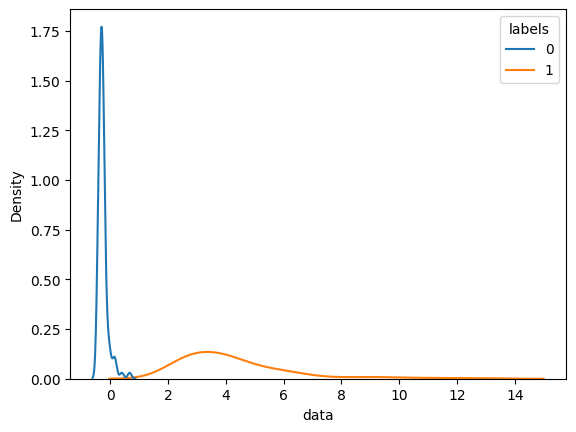

In [66]:
# Perform clustering for dbe
kmeans_dbe = KMeans(init="k-means++", n_clusters=2, n_init=4, random_state=0)
label_dbe = kmeans_dbe.fit_predict(data_dbe.reshape(-1, 1))

visualize_density_plots(data_dbe, label_dbe)

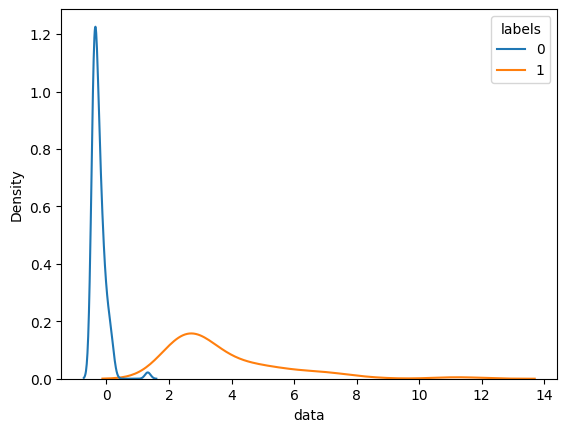

In [67]:
# Perform clustering for dbn
kmeans_dbn = KMeans(init="k-means++", n_clusters=2, n_init=4, random_state=0)
label_dbn = kmeans_dbn.fit_predict(data_dbn.reshape(-1, 1))

visualize_density_plots(data_dbn, label_dbn)

In [68]:
# Find majority class and density function

def majority_class_density(labels):
    filtered_labels_0 = labels[labels == 0]
    filtered_labels_1 = labels[labels == 1]
    if len(filtered_labels_0) > len(filtered_labels_1):
        majority_class = 0
        class_density = len(filtered_labels_0) / (len(filtered_labels_0) + len(filtered_labels_1))
    else:
        majority_class = 1
        class_density = len(filtered_labels_1) / (len(filtered_labels_0) + len(filtered_labels_1))
    return majority_class, class_density

In [69]:
# Find the class and density
majority_class_dbe, density_dbe = majority_class_density(label_dbe)
majority_class_dbn, density_dbn = majority_class_density(label_dbn)
weight_minority_class_dbe = density_dbe / (1 - density_dbe)
weight_minority_class_dbn = density_dbn / (1 - density_dbn)

In [70]:
majority_class_dbe, weight_minority_class_dbe

(0, 35.61742410798043)

In [71]:
majority_class_dbn, weight_minority_class_dbn

(0, 31.020134168672982)

In [72]:
# Function to add labels and weights

def process_data(feature_dict):
    dbn = feature_dict['future_supermag'][0, :, 2]
    dbe = feature_dict['future_supermag'][0, :, 2]
    
    dbn = np.abs(data_dbn)
    dbe = np.abs(data_dbe)
    dbn[np.isnan(data_dbn)] = 0
    dbe[np.isnan(data_dbe)] = 0
    dbn = (dbn - data_dbn_mean) / data_dbn_std
    dbe = (dbe - data_dbe_mean) / data_dbe_std
    
    labels_dbe = kmeans_dbe.predict(dbe)
    labels_dbn = kmeans_dbn.predict(dbn)
    
    weights_dbe = np.ones_like(dbe)
    weights_dbn = np.ones_like(dbn)
    
    weights_dbe[labels_dbe != majority_class_dbe] = weight_minority_class_dbe
    weights_dbn[labels_dbn != majority_class_dbn] = weight_minority_class_dbn
    
    feature_dict['weights_dbe'] = weights_dbe
    feature_dict['weights_dbn'] = weights_dbn
    return feature_dict
    

In [ ]:
for year in yearlist:
    features_year = pickle.load(open(os.path.join(preprocessed_path, f'train_data_{year}.p'), 'rb'))
    new_features_year = []
    features_list = process_map(process_data, [features_year[i] for i in range(len(features_year))], max_workers = num_workers, chunksize = 1)
    with open(os.path.join(preprocessed_path, f'train_with_weights_data_{year}'), 'rb') as f:
        pickle.dump(features_list, f, pickle.HIGHEST_PROTOCOL)
